## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 


In [29]:
import pandas as pd
import numpy as np

golub = pd.read_csv("./data/golub.csv")

mappings = {
    "allB": 0,
    "allT": 0,
    "aml": 1
}
golub["cancer"] = golub["cancer"].map(mappings)
golub["cancer"].value_counts()

cancer
0    47
1    25
Name: count, dtype: int64


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 


Mean Squared Error: 6.765406708643482e-30


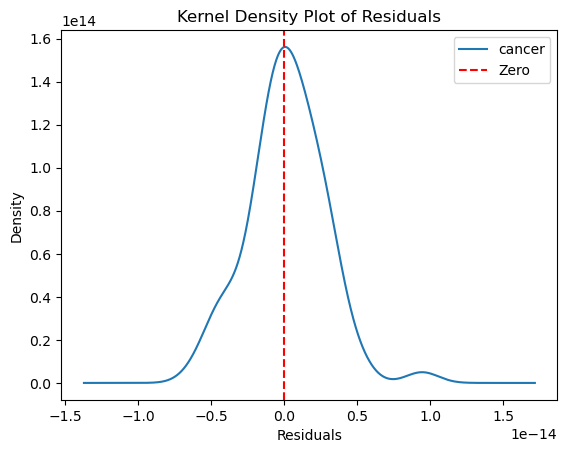

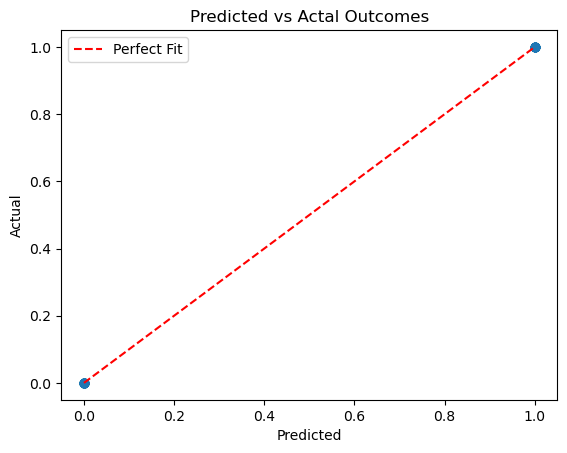

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 
import matplotlib.pyplot as plt

golub.columns

X = golub.drop(columns=['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer'])
y = golub["cancer"]

model = LinearRegression()
model.fit(X, y)

predicted = model.predict(X)
mse = mean_squared_error(y, predicted)
print("Mean Squared Error:", mse)

residuals = y - predicted

plt.figure()
residuals.plot.kde()
plt.title("Kernel Density Plot of Residuals")
plt.xlabel("Residuals")
plt.axvline(0, color='red', linestyle='--', label='Zero')
plt.legend()
plt.show()

plt.figure()
plt.scatter(predicted, y, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Fit')
plt.title("Predicted vs Actal Outcomes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.legend()
plt.show()
plt.show()




3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

* **The low training error stems potentially from the fact that the number of genes is much greater than the number of patients and therefore samples in the data, giving the model enough freedom to perfectly memorize the training labels, but make incorrect predictions on new patient data. This results in a high variance, low bias model as seen by the CV MSE jumping to 0.060 despite a near-zero training MSE.**

In [31]:
from sklearn.model_selection import cross_val_score

cv_mse = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print("Cross-Validated MSE per fold:", cv_mse)
print("Average Cross-Validated MSE:", cv_mse.mean())

Cross-Validated MSE per fold: [0.04872133 0.07295289 0.04721866 0.04686773 0.08485489]
Average Cross-Validated MSE: 0.06012309872062118



4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 


Best alpha: 105.24436668425457
Number of selected genes: 34
Number of discarded genes: 7095
Selected genes: ['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at']


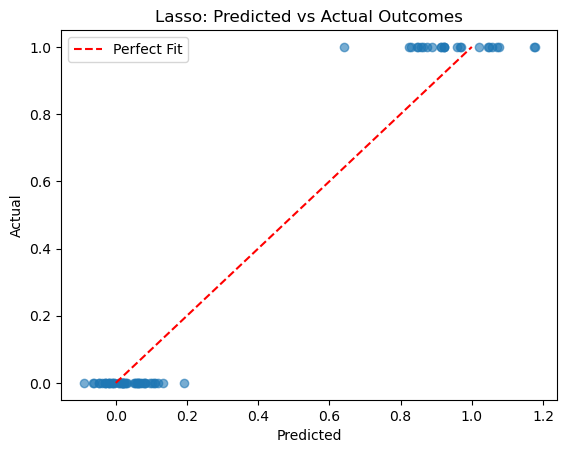

In [32]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(cv=5, max_iter=1000, random_state=42)
lasso_cv.fit(X, y)

selected_genes = X.columns[lasso_cv.coef_ != 0]
discarded_genes = X.columns[lasso_cv.coef_ == 0]

print("Best alpha:", lasso_cv.alpha_)
print("Number of selected genes:", len(selected_genes))
print("Number of discarded genes:", len(discarded_genes))
print("Selected genes:", list(selected_genes))

lasso_predicted = lasso_cv.predict(X)

plt.figure()
plt.scatter(lasso_predicted, y, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect Fit')
plt.title("Lasso: Predicted vs Actual Outcomes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.legend()
plt.show()


5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

* **The LASSO is overfitting at low alpha values (below ~100) where the penalty is too weak to constrain the thousands of gene features, and underfitting at high alpha values (above ~100) where the penalty is so strong it zeroes out too many genes. The optimal alpha is 105.24, sitting at the bottom of the U-curve where CV MSE is minimized.**

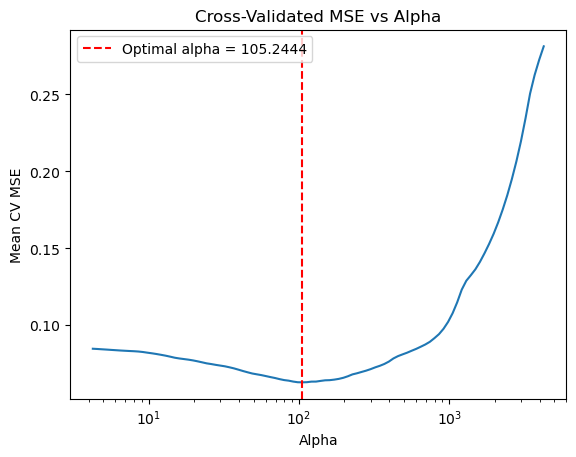

In [33]:
alphas = lasso_cv.alphas_
mse_path = lasso_cv.mse_path_.mean(axis=1)

plt.figure()
plt.plot(alphas, mse_path)
plt.xscale('log')
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Optimal alpha = {lasso_cv.alpha_:.4f}')
plt.title("Cross-Validated MSE vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.legend()
plt.show()


6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

* **Linear regression has thousands of gene features but only 72 samples, so it can perfectly memorize the training labels by assigning arbitrary coefficients to each gene, resulting in a training MSE of essentially zero but poor generalization. LASSO adds an L1 penalty that forces most gene coefficients to exactly zero, keeping only the most predictive genes (discarding 7095 of them), which prevents memorization and produces a model that actually generalizes to unseen data.**



7. Why do regularization methods lend themselves to scenarios like precision health? 


* **In precision health, you often see far more features than patients. By being able to force most coefficients to zero, these regularization methods like LASSO can produce interpretable models that identify just a small set of biolgoically meaningful markers. This is crucial in medicine where you must gather intution behind a decision/prediction.**


8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

* **Due to the intrinsic smaller sample sizes, LASSO models may overfit to small data and select genes that appear predictive by chance rather than true biological signal. Additionally, if training data is unknowingly biased, it may not be representative of greater medical populations, meaning the predictions may be poor which can lead to potentially harmful interventions.**